# AHA 17-Segment Bullseye Diagram

Builds the standard AHA 17-segment polar map (bullseye) for left ventricular analysis.

**AHA 17-Segment Layout (viewed from apex toward base):**
- **Outermost ring** — Basal (segments 1–6), 60° each
- **Middle ring** — Mid-cavity (segments 7–12), 60° each
- **Inner ring** — Apical (segments 13–16), 90° each
- **Centre** — Apex (segment 17)

**Orientation:** Anterior at top (12 o'clock), Lateral at left (9 o'clock), Inferior at bottom (6 o'clock), Septal at right (3 o'clock).

Segments are numbered counterclockwise starting from Anterior.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import matplotlib.cm as cm

## AHA Segment Definitions

Each entry specifies:
- `idx`: AHA segment number (1–17)
- `name`: anatomical name
- `ring`: 0=Basal, 1=Mid-cavity, 2=Apical, 3=Apex
- `t1`, `t2`: start/end angles in degrees (counterclockwise, 90°=Anterior/top)

In [9]:
# Ring radii: (outer_radius, inner_radius)
RING_RADII = [
    (1.00, 0.65),  # ring 0 — Basal
    (0.65, 0.40),  # ring 1 — Mid-cavity
    (0.40, 0.18),  # ring 2 — Apical
    (0.18, 0.00),  # ring 3 — Apex (full disk)
]

# Angles: counterclockwise from 0° (right/3-o'clock).
# 90° = Anterior (top/12-o'clock), 180° = Lateral (left/9-o'clock),
# 270° = Inferior (bottom/6-o'clock), 0°/360° = Septal (right/3-o'clock)
AHA_SEGMENTS = [
    # --- Basal (ring 0, 6 × 60°) ---
    {"idx":  1, "name": "Basal Anterior",      "ring": 0, "t1":  60, "t2": 120},
    {"idx":  2, "name": "Basal Anterolateral", "ring": 0, "t1": 120, "t2": 180},
    {"idx":  3, "name": "Basal Inferolateral", "ring": 0, "t1": 180, "t2": 240},
    {"idx":  4, "name": "Basal Inferior",      "ring": 0, "t1": 240, "t2": 300},
    {"idx":  5, "name": "Basal Inferoseptal",  "ring": 0, "t1": 300, "t2": 360},
    {"idx":  6, "name": "Basal Anteroseptal",  "ring": 0, "t1":   0, "t2":  60},
    # --- Mid-cavity (ring 1, 6 × 60°) ---
    {"idx":  7, "name": "Mid Anterior",        "ring": 1, "t1":  60, "t2": 120},
    {"idx":  8, "name": "Mid Anterolateral",   "ring": 1, "t1": 120, "t2": 180},
    {"idx":  9, "name": "Mid Inferolateral",   "ring": 1, "t1": 180, "t2": 240},
    {"idx": 10, "name": "Mid Inferior",        "ring": 1, "t1": 240, "t2": 300},
    {"idx": 11, "name": "Mid Inferoseptal",    "ring": 1, "t1": 300, "t2": 360},
    {"idx": 12, "name": "Mid Anteroseptal",    "ring": 1, "t1":   0, "t2":  60},
    # --- Apical (ring 2, 4 × 90°) ---
    {"idx": 13, "name": "Apical Anterior",     "ring": 2, "t1":  45, "t2": 135},
    {"idx": 14, "name": "Apical Lateral",      "ring": 2, "t1": 135, "t2": 225},
    {"idx": 15, "name": "Apical Inferior",     "ring": 2, "t1": 225, "t2": 315},
    {"idx": 16, "name": "Apical Septal",       "ring": 2, "t1": -45, "t2":  45},
    # --- Apex (ring 3, full circle) ---
    {"idx": 17, "name": "Apex",                "ring": 3, "t1":   0, "t2": 360},
]

RING_NAMES = ["Basal", "Mid-cavity", "Apical", "Apex"]

print(f"Total segments defined: {len(AHA_SEGMENTS)}")

Total segments defined: 17


## Bullseye Render Function

In [3]:
def draw_bullseye(
    values=None,
    title="AHA 17-Segment Bullseye",
    cmap="RdYlGn",
    vmin=None,
    vmax=None,
    label_fontsize=9,
    show_names=False,
    ax=None,
):
    """
    Render the AHA 17-segment bullseye.

    Parameters
    ----------
    values : array-like of length 17, or None
        One value per AHA segment (index 0 = segment 1 ... index 16 = segment 17).
        Pass None to draw geometry-only (uniform light-blue fill).
    title : str
    cmap : matplotlib colormap name
    vmin, vmax : colormap range; inferred from values if None
    label_fontsize : font size for the segment index labels
    show_names : if True, show short anatomical abbreviations instead of numbers
    ax : existing matplotlib Axes to draw on; creates a new figure if None
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 7))

    ax.set_aspect("equal")
    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.25, 1.25)
    ax.axis("off")

    # Colormap setup
    if values is not None:
        vals = np.asarray(values, dtype=float)
        _vmin = vmin if vmin is not None else vals.min()
        _vmax = vmax if vmax is not None else vals.max()
        norm = Normalize(vmin=_vmin, vmax=_vmax)
        cmap_fn = cm.get_cmap(cmap)

    # Orientation labels (Anterior/Inferior/Lateral/Septal)
    for angle, label in [(90, "ANT"), (270, "INF"), (180, "LAT"), (0, "SEPT")]:
        rad = np.radians(angle)
        ax.text(
            1.15 * np.cos(rad), 1.15 * np.sin(rad),
            label, ha="center", va="center",
            fontsize=8, color="dimgray", fontweight="bold"
        )

    # Draw each segment
    for seg in AHA_SEGMENTS:
        r_out, r_in = RING_RADII[seg["ring"]]
        width = r_out - r_in
        t1, t2 = seg["t1"], seg["t2"]

        # Segment fill colour
        if values is not None:
            face_color = cmap_fn(norm(vals[seg["idx"] - 1]))
        else:
            face_color = "#aed6f1"  # geometry-only: uniform light blue
        wedge = mpatches.Wedge(
            center=(0, 0),
            r=r_out,
            theta1=t1,
            theta2=t2,
            width=width,
            facecolor=face_color,
            edgecolor="black",
            linewidth=0.8,
        )
        ax.add_patch(wedge)

        # Label position: centroid of the wedge
        theta_mid = np.radians((t1 + t2) / 2)
        if seg["ring"] == 3:
            lx, ly = 0.0, 0.0  # apex is at centre
        else:
            r_mid = (r_out + r_in) / 2
            lx = r_mid * np.cos(theta_mid)
            ly = r_mid * np.sin(theta_mid)
        label_text = str(seg["idx"]) if not show_names else seg["name"].split()[-1][:4]
        ax.text(
            lx, ly, label_text,
            ha="center", va="center",
            fontsize=label_fontsize, fontweight="bold", color="black"
        )
    ax.set_title(title, fontsize=12, pad=10)
    if standalone:
        plt.tight_layout()
        plt.show()

print("draw_bullseye() ready.")

draw_bullseye() ready.


## Demo 1 — Geometry Only
Renders all 17 segments with their AHA index labels and no data values.
Confirms correct shape, ring proportions, and orientation.

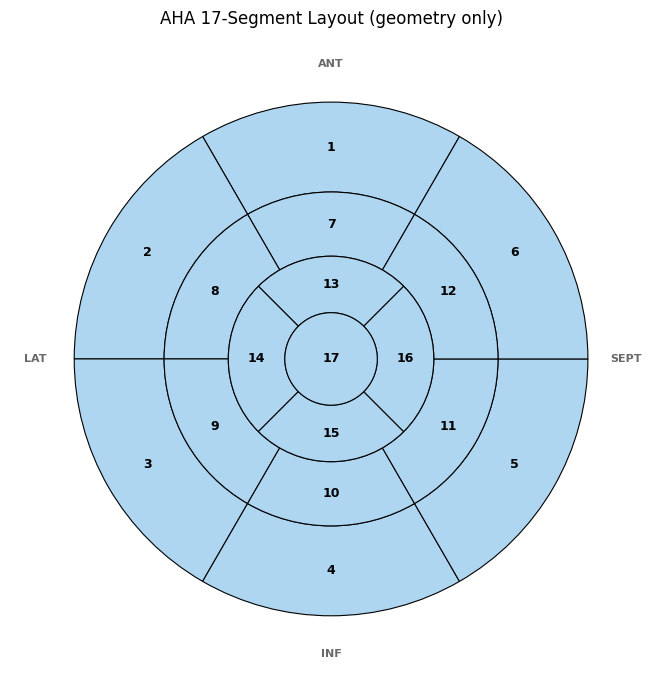

In [4]:
draw_bullseye(values=None, title="AHA 17-Segment Layout (geometry only)")

## Demo 2 — Colour-Coded with Synthetic Values

Simulates an inferior wall perfusion defect (segments 4, 5, 10, 11 at low values).

C:\Users\hp193\AppData\Local\Temp\ipykernel_12776\2742187691.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_fn = cm.get_cmap(cmap)


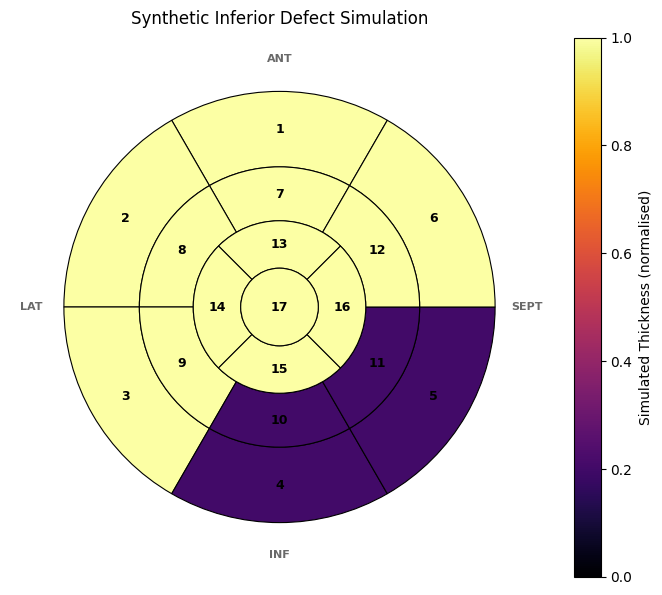

In [5]:
# Normal thickness ~ 1.0, defect region ~ 0.2
synthetic_data = np.ones(17)
defect_segments = [4, 5, 10, 11] # Inferior and inferoseptal (basal/mid)
for seg in defect_segments:
    synthetic_data[seg - 1] = 0.2  # zero-indexed arrays

fig, ax = plt.subplots(figsize=(8, 7))
draw_bullseye(
    values=synthetic_data,
    title="Synthetic Inferior Defect Simulation",
    cmap="inferno",
    vmin=0.0,
    vmax=1.0,
    ax=ax
)

# Add colourbar via scalar mappable
sm = cm.ScalarMappable(cmap="inferno", norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Simulated Thickness (normalised)")

plt.show()

## Phase 2 Inference Connection (Placeholder)
When volumetric thickness arrays are produced by `bullseye_analysis.py`, they can be passed directly to this renderer.

In [10]:
def process_and_plot_real_data(segment_thickness_array):
    """
    Accepts 17-element array from the backend inference pipeline and plots it.
    """
    if len(segment_thickness_array) != 17:
        raise ValueError("Must provide exactly 17 segment values.")
    
    fig, ax = plt.subplots(figsize=(8, 7))
    draw_bullseye(
        values=segment_thickness_array,
        title="Patient Thickness Mapping",
        cmap="coolwarm",
        ax=ax
    )
    plt.show()

# E.g., process_and_plot_real_data(np.random.rand(17))